# Milestone 4 (alternate) — Weekly and Monthly Forecast Horizons

**Team:** Stephanie Nord, David Jorgensen, Joshua Amaya
**Course project:** predicting hive weight change from colony sensor history

---

## What this notebook is

`Milestone_4.ipynb` predicts **tomorrow's** change in daily-mean hive weight. Its central
result is a negative one: no single-stage learned model beats predicting zero, and only a
two-stage classifier→regressor pipeline clears the naive bar, at **+5.9% skill**. The
day-to-day change series is close to noise-dominated.

This notebook asks the obvious follow-up. **If we forecast week-to-week or month-to-month
instead, what has to change, and is the answer any better?**

It is a companion, not a replacement. Everything about the source data, its provenance,
the publishers' preprocessing, the leakage controls and the extreme-event investigation
carries over unchanged from `Milestone_4.ipynb` Sections 2 and 3, and is not repeated
here. What is repeated is every part of the protocol that the grain change touches — which
turns out to be most of it.

## How to run this notebook

```bash
pip install -r requirements.txt
jupyter nbconvert --to html --execute Milestone_4_alt.ipynb
```

Every number and figure is computed at run time from
`data/honey_model.parquet`. The re-grain logic lives in `src/honeymodel/periods.py`.

## The seven things that had to change

| # | What changes | Section | Consequence if skipped |
|---|---|---|---|
| 1 | **The target's anchor** — mean-of-period vs last-day-of-period | 2.3 | Decides whether the model beats its baseline at all |
| 2 | **A coverage gate** — a week from 2 readings is not a week | 2.2 | Target noise scales with how many days happened to report |
| 3 | **Every feature rebuilt** — daily lags are daily constructs | 2.4 | `previous_day_weight_kg` has no meaning at week grain |
| 4 | **An embargo at the split boundary** | 4.1 | Training labels measured inside the test window |
| 5 | **New baselines** — calendar climatology becomes a real competitor | 4.3 | Skill score credits the model for knowing July gains |
| 6 | **A re-derived extreme threshold** — ±5 kg stops meaning extreme | 3.2 | The two-stage pipeline silently models a different thing |
| 7 | **Sample size falls 9× (week) / 42× (month)** | 2.2 | Model capacity and fold count no longer fit the data |
| 8 | **Comparability** — MAE across grains measures different things | 6.2 | Only the skill score can be read across the three horizons |

## Headline

Re-graining to a **week**, with the target anchored on **period mean weight**, produces the
first configuration in this project where a *single-stage* model beats its naive baseline.
A two-stage pipeline at the re-derived threshold more than doubles the daily milestone's
skill score (+15.2% against +5.9%). Section 6.2 puts the two side by side.

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from honeymodel import data, evaluation as ev, models, periods as pr

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SEED = 42
N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS = 4, 6, 12

# The event-distance columns are normalised on load: the published *_last_dif values are
# in days for 33 hives and seconds for 24, and the period aggregate takes the last value
# in each period, so an un-normalised column would mix units inside one feature.
daily_df = data.add_season(data.normalise_event_distance_units(data.load_model_table()))

print(f"daily rows : {len(daily_df):,}")
print(f"hives      : {daily_df.hive_id.nunique()}")
print(f"date range : {daily_df.measurement_date.min().date()} to {daily_df.measurement_date.max().date()}")

daily rows : 26,215
hives      : 78
date range : 2019-06-25 to 2022-12-30


## 2. Re-graining the Data

### 2.1 Why the grain is the question, not a parameter

The daily target has a standard deviation of 1.84 kg against a colony mean weight of
34.3 kg, and `Milestone_4.ipynb` Section 4.3 shows that repeating yesterday's change is
the *worst* of five naive rules (R² −0.58). A series that is anti-persistent at lag 1 is
a series where most of what moves day to day is not colony behaviour.

Two mechanisms make a longer period plausibly easier, and they pull in opposite directions
from the sample-size cost:

- **Independent day-level noise cancels.** Scale sensor noise, a re-tare, a rain-soaked
  roof drying out — these average toward zero over five to seven days.
- **Beekeeper handling artifacts damp.** Section 3.5 of the daily milestone establishes
  that 94% of its "extreme events" are the >0.3 kg/min jumps the publishers attribute to
  beekeeper handling. A jump that is reversed within the same week largely cancels in a
  period *mean*; one that is not reversed is a real mass change.
- **Nectar flow accumulates.** The signal grows roughly linearly with the period while
  independent noise grows as its square root.

Against that, the row count collapses and the seasonal regimes stop being separable by
averaging. The rest of Section 2 makes the cost explicit before Section 5 measures the
benefit.

### 2.2 Aggregation and the coverage waterfall

In [2]:
waterfalls = {grain: pr.coverage_waterfall(daily_df, grain) for grain in ("week", "month")}
for grain, table in waterfalls.items():
    print(f"--- {grain} " + "-" * 52)
    print(table.to_string(index=False))

--- week ----------------------------------------------------
                                   step  rows_remaining  rows_dropped
                    daily rows ingested           26215             0
               aggregated to hive-weeks            4275         21940
     coverage gate (>= 5 observed days)            3510           765
 next period contiguous (target exists)            3012           498
previous period contiguous (lag exists)            2631           381
--- month ----------------------------------------------------
                                   step  rows_remaining  rows_dropped
                    daily rows ingested           26215             0
              aggregated to hive-months            1149         25066
    coverage gate (>= 20 observed days)             814           335
 next period contiguous (target exists)             622           192
previous period contiguous (lag exists)             477           145


Aggregation is not free and this notebook does not treat it as bookkeeping. Three gates
fire, and each is a decision somebody could reasonably disagree with:

**The coverage gate.** A "week" reconstructed from two observed days is a different
measurement from one reconstructed from seven, and the difference lands directly in the
target. With 23–35% sensor missingness upstream, weeks with thin coverage are common. The
gate is ≥5 observed days for a week and ≥20 for a month.

**Contiguity, in both directions.** The target is the change over the *next* period, so a
row needs its successor present and adjacent in `period_index`. The lag features need the
predecessor. Contiguity is checked on the period index, not on dates — a hive that goes
dark for three weeks has no valid change across the gap, and interpolating one would
fabricate the single most important feature in the model.

The result: **26,215 hive-days become 3,012 usable hive-weeks or 622 hive-months** — a 9×
and 42× reduction. After the coverage gate a hive contributes a median of 42 weeks or 10
months, and the target requirement trims that further. Those counts govern everything in
Section 5, and they are why the monthly result carries a caveat that the weekly one does
not.

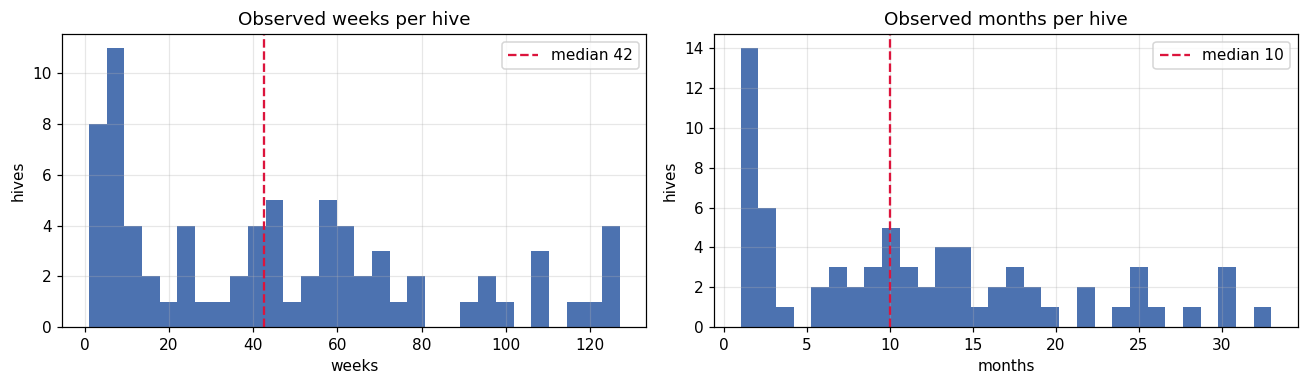

week : 3,510 hive-weeks, median 42 per hive
month: 814 hive-months, median 10 per hive


In [3]:
week_raw = pr.aggregate_to_period(daily_df, "week")
month_raw = pr.aggregate_to_period(daily_df, "month")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (grain, table) in zip(axes, [("week", week_raw), ("month", month_raw)]):
    counts = table.groupby("hive_id").size()
    ax.hist(counts, bins=30, color="#4c72b0", edgecolor="none")
    ax.axvline(counts.median(), color="crimson", linestyle="--",
               label=f"median {int(counts.median())}")
    ax.set(title=f"Observed {grain}s per hive", xlabel=f"{grain}s", ylabel="hives")
    ax.legend()
plt.tight_layout(); plt.show()

print(f"week : {len(week_raw):,} hive-weeks, median {int(week_raw.groupby('hive_id').size().median())} per hive")
print(f"month: {len(month_raw):,} hive-months, median {int(month_raw.groupby('hive_id').size().median())} per hive")

### 2.3 The anchor decision

"How much weight did the hive gain this week" has two defensible readings, and this is
the single most consequential choice in the notebook.

| Anchor | Definition | Property |
|---|---|---|
| `last` | change between the **last observed day** of each period | Consecutive changes partition the record exactly and sum to its total change — the property a mass balance should have. But the whole target rests on two single-day readings, so day-level noise and un-reversed handling jumps survive aggregation at full amplitude. |
| `mean` | change between **period mean weights** | Averaging over 5–7 days cancels independent noise and damps a single-day spike to roughly a seventh of its amplitude. Gives up exact additivity: consecutive mean-to-mean changes overlap in what they measure. |

There is a tiebreaker from the level below. `end_of_day_weight_kg` is itself a *misnomer*
— the publishers compute it as the mean of the day's minute readings, not the last one
(`Milestone_4.ipynb` §2.2). Anchoring on a period mean is the choice that keeps the grain
change consistent with what the daily grain already does.

The head-to-head decides it, not the argument:

In [4]:
def prepare(grain, anchor="mean", min_days=None):
    # Aggregate -> chain features and target -> drop rows with no successor period.
    aggregated = pr.aggregate_to_period(daily_df, grain, min_days=min_days)
    framed = pr.add_period_features(aggregated, anchor=anchor)
    return framed.dropna(subset=[pr.PERIOD_TARGET]).reset_index(drop=True)


def protocol(frame, feature_set="history", model_name="rf", seed=SEED):
    # One place for the whole protocol: folds -> baselines -> matrix -> per-fold results.
    folds = pr.rolling_origin_period_cv(frame, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS)
    baselines = pr.period_baseline_board(frame, folds)
    matrix = pr.build_period_matrix(frame, feature_set)
    if model_name not in models.NATIVE_NAN_MODELS:  # RF and linear cannot take NaN
        matrix = pr.PeriodMatrix(matrix.X.fillna(matrix.X.median()), matrix.y,
                                 matrix.meta, matrix.frame, matrix.feature_names)
    results = pr.evaluate_period_folds(
        matrix, folds, lambda: models.make_regressor(model_name, seed=seed), model_name, baselines
    )
    return folds, baselines, matrix, results


rows = []
for grain in ("week", "month"):
    for anchor in ("last", "mean"):
        frame = prepare(grain, anchor)
        _, baselines, _, results = protocol(frame)
        rows.append({
            "grain": grain, "anchor": anchor, "n": len(frame),
            "target_sd": frame[pr.PERIOD_TARGET].std(),
            "best_naive": baselines.groupby("model").mae.mean().idxmin(),
            "naive_mae": baselines.groupby("fold").mae.min().mean(),
            "rf_mae": results.mae.mean(),
            "skill_vs_naive": results.skill_vs_naive.mean(),
        })
anchor_table = pd.DataFrame(rows)
display(anchor_table.round(4))

,grain,anchor,n,target_sd,best_naive,naive_mae,rf_mae,skill_vs_naive
0,week,last,3012,4.9554,train_mean,2.2858,2.6989,-0.2361
1,week,mean,3012,4.0950,predict_zero,1.9601,1.7020,0.0866
2,month,last,622,8.8377,predict_zero,5.2503,6.3638,-0.2156
3,month,mean,622,8.0441,month_climatology,4.8622,4.3502,0.0934


**The anchor decides the result.** On the last-day anchor a Random Forest *loses* to the
naive bar at both grains. On the period-mean anchor it wins at both. Same rows, same
features, same folds, same model — the difference is entirely in what "this week's weight"
was taken to mean.

That is worth stating plainly because it is the kind of choice that usually gets made in
one line of a groupby and never revisited. Note also that the mean anchor shrinks the
target's standard deviation from 4.96 to 4.10 kg at week grain: it is not merely a
smoother target, it is a target with visibly less of the handling-artifact variance that
Section 3.5 of the daily milestone identified.

The rest of this notebook uses `anchor="mean"`.

### 2.4 Features and leakage controls at the new grain

Every feature in the daily model is a daily construct. `previous_day_weight_kg`,
`rolling_3_day_weight_kg`, `weight_slope_2_day_kg` — none of them mean anything at week
grain, and none of them survive the re-grain. `periods.py` rebuilds the ladder:

- **Weight chain**: period weight, previous period weight, this period's change, previous
  period's change, 4-period rolling mean and sd of change, deviations from those rollings.
- **Within-period shape** — new, and it has no daily analogue: the OLS slope of daily
  weight across the period, the sd of daily weight inside it, and the largest single-day
  change. A week that gained 2 kg steadily and a week that gained 2 kg in one jump are
  different weeks, and only these features can tell them apart.
- **Sensors**: mean, sd and max per period rather than a single daily reading, plus
  `foraging_days`, the count of days above 12 °C.
- **Events**: days since each logged beekeeper event, past-facing only.
- **Coverage**: `days_observed` for this period and the last, so the model can see when a
  row is built from thin data.

The leakage rule is restated at this grain rather than inherited. A shared `FORBIDDEN`
frozenset would have passed every period column through silently, because none of the
daily names exist here.

In [5]:
print(f"{len(pr.PERIOD_FORBIDDEN)} forbidden period columns:")
for column in sorted(pr.PERIOD_FORBIDDEN):
    print(f"  {column}")

# Negative test: asking for a forbidden column must fail, not quietly produce a model.
week_df = prepare("week")
try:
    pr.build_period_matrix(week_df, ["period_weight_kg", pr.PERIOD_TARGET])
    raise SystemExit("LEAKAGE GUARD FAILED -- the target reached a feature matrix")
except pr.PeriodLeakageError as error:
    print(f"\nnegative test passed: {error}")

print(f"\nfeature sets: {list(pr.PERIOD_FEATURE_SETS)}")
print(f"history rung: {len(pr.PERIOD_FEATURE_SETS['history'])} features")

13 forbidden period columns:
  died_next_dif_days
  feeding_next_dif_days
  honey_next_dif_days
  next_period_days_observed
  next_period_index
  next_period_start_date
  next_period_weight_kg
  period_extreme_flag
  period_extreme_relative_flag
  queencell_next_dif_days
  swarming_next_dif_days
  target_next_period_weight_change_kg
  treatment_next_dif_days

negative test passed: these columns are only knowable after the period ends, or are derived from the label, and must not be used as features: ['target_next_period_weight_change_kg']

feature sets: ['history', 'history+sensors', 'history+sensors+events', 'history+sensors+events+hive']
history rung: 19 features


## 3. What the Re-grain Does to the Target

### 3.1 Distribution across the three grains

,grain,n,sd,mae_predict_zero,pct_abs_gt_5kg,5kg_in_sd
0,day,26215,1.841,0.525,1.698,2.717
1,week,3012,4.095,1.962,10.425,1.221
2,month,622,8.044,4.661,29.260,0.622


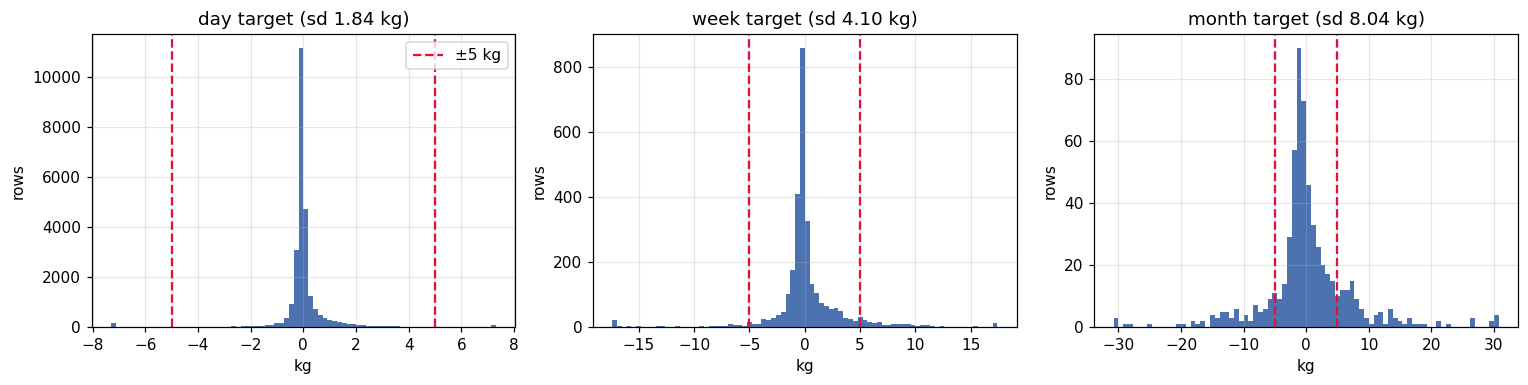

In [6]:
month_df = prepare("month")
targets = {
    "day": daily_df.target_next_day_weight_change_kg.dropna(),
    "week": week_df[pr.PERIOD_TARGET],
    "month": month_df[pr.PERIOD_TARGET],
}

summary = pd.DataFrame([
    {"grain": grain, "n": len(values), "sd": values.std(),
     "mae_predict_zero": values.abs().mean(),
     "pct_abs_gt_5kg": 100 * (values.abs() > 5).mean(),
     "5kg_in_sd": 5 / values.std()}
    for grain, values in targets.items()
])
display(summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, (grain, values) in zip(axes, targets.items()):
    limit = np.percentile(values.abs(), 99)
    ax.hist(values.clip(-limit, limit), bins=80, color="#4c72b0", edgecolor="none")
    for sign in (-1, 1):
        ax.axvline(sign * 5, color="crimson", linestyle="--")
    ax.set(title=f"{grain} target (sd {values.std():.2f} kg)", xlabel="kg", ylabel="rows")
axes[0].legend(["±5 kg"], loc="upper right")
plt.tight_layout(); plt.show()

### 3.2 ±5 kg stops meaning "extreme"

The daily milestone splits the target at ±5 kg, giving a 1.7% positive rate, and builds a
two-stage classifier→regressor pipeline around that split. The threshold was inherited by
convention; §3.6 sweeps it and finds the trade-off mild.

Carrying it across the grain change is not mild. Five kilograms is 2.7 daily standard
deviations but only 1.2 weekly ones. The same number now selects **10.4% of weeks** — no
longer a tail, and no longer the thing the two-stage architecture was designed around.

In [7]:
sweep = pr.period_threshold_sweep(week_df, [3, 5, 7, 10, 11.1, 13.5, 20])
display(sweep)

WEEK_THRESHOLD = round(pr.relative_extreme_threshold(week_df[pr.PERIOD_TARGET]), 1)
daily_rate = 100 * (targets["day"].abs() > 5).mean()
print(f"daily rule: 5.0 kg = 2.7 daily sd  -> {daily_rate:.2f}% of hive-days extreme")
print(f"same 5.0 kg at week grain          -> {100 * (week_df[pr.PERIOD_TARGET].abs() > 5).mean():.2f}% of hive-weeks")
print(f"re-derived at 2.7 weekly sd        -> {WEEK_THRESHOLD} kg")

,threshold_kg,n_extreme,positive_rate_pct,threshold_in_sd
0,3.0,542,17.99,0.73
1,5.0,314,10.42,1.22
2,7.0,199,6.61,1.71
3,10.0,111,3.69,2.44
4,11.1,91,3.02,2.71
5,13.5,63,2.09,3.30
6,20.0,22,0.73,4.88


daily rule: 5.0 kg = 2.7 daily sd  -> 1.70% of hive-days extreme
same 5.0 kg at week grain          -> 10.42% of hive-weeks
re-derived at 2.7 weekly sd        -> 11.1 kg


**The threshold is re-derived in standard-deviation units, not carried over in kilograms.**
At 2.7 weekly sd it lands at **11.1 kg**, selecting 3.0% of weeks. Section 5.3 uses this
figure.

Note that matching the sd multiple does *not* reproduce the daily 1.7% positive rate — it
gives 3.0%, and reproducing 1.7% would need 13.5 kg (3.3 sd). Only one of the two can be
held fixed, and the discrepancy is itself a measurement: the same number of standard
deviations captures more of the weekly distribution than of the daily one, so the weekly
target is **less heavy-tailed relative to its own spread**. That is what aggregation is
expected to do — averaging five to seven days pulls the distribution toward Gaussian and
strips exactly the single-day spikes that made the daily tail so fat. It is independent
corroboration of the mechanism argued in Section 2.1, arriving from the threshold sweep
rather than from the anchor comparison.

The sd multiple is the quantity carried across, because it is the one that means the same
thing at both grains.

An absolute threshold remains the wrong shape for this problem at any grain: 11 kg on a
10 kg nucleus and 11 kg on a 100 kg production hive are not the same event, and the hives
here span 0–111.7 kg. A per-hive relative rule is the honest fix and is left as future
work, exactly as in the daily milestone.

## 4. Validation Framework

### 4.1 The embargo — the one genuinely new correctness requirement

The daily splitter is safe for a reason that stops being true here. A daily row's label
lands one day later, so cutting the training set at the origin date leaves at most one day
of overlap, and `assert_split_integrity` catches it.

At week grain a row's label is measured over the **following period** — up to 7 days after
its features. A training row whose features predate the origin can carry a label that was
measured *inside the test window*. Applying the daily rule here trains on the test set,
and the daily assertion, which compares feature dates, passes it.

`rolling_origin_period_cv` therefore states the rule on the label: a training row is
admitted only when its `target_period_end_date` falls strictly before the first test
observation. `embargo=False` reproduces the unsafe daily rule so the cost can be measured
rather than asserted.

In [8]:
embargo_rows = []
for embargo in (True, False):
    folds = pr.rolling_origin_period_cv(week_df, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS,
                                        embargo=embargo)
    baselines = pr.period_baseline_board(week_df, folds)
    matrix = pr.build_period_matrix(week_df, "history")
    matrix = pr.PeriodMatrix(matrix.X.fillna(matrix.X.median()), matrix.y, matrix.meta,
                             matrix.frame, matrix.feature_names)
    results = pr.evaluate_period_folds(
        matrix, folds, lambda: models.make_regressor("rf", seed=SEED), "rf", baselines
    )
    embargo_rows.append({
        "embargo": embargo,
        "train_rows": sum(len(fold.train_index) for fold in folds),
        "rows_embargoed": sum(fold.extra["embargoed_rows"] for fold in folds),
        "mae": results.mae.mean(),
        "skill_vs_naive": results.skill_vs_naive.mean(),
    })
display(pd.DataFrame(embargo_rows).round(4))

# The daily assertion compares feature dates and passes the unsafe split; the period
# assertion compares label dates and rejects it.
unsafe = pr.rolling_origin_period_cv(week_df, N_SPLITS, HORIZON_MONTHS, MIN_TRAIN_MONTHS,
                                     embargo=False)
try:
    pr.assert_period_split_integrity(week_df, unsafe[0])
    print("\nno overlap detected in fold 1 without the embargo")
except AssertionError as error:
    print(f"\nperiod assertion rejects the un-embargoed split: {error}")

,embargo,train_rows,rows_embargoed,mae,skill_vs_naive
0,True,5281,100,1.7020,0.0866
1,False,5381,0,1.7471,0.0395



period assertion rejects the un-embargoed split: fold_1_2020-07-22: a training label ends 2020-08-02 but the test window opens 2020-07-22 -- the label was measured inside the test period


The embargo removes **100 of 5,381 training rows (1.9%)**, and — reported as measured, not
as hoped — the un-embargoed split does not score *better*. Its MAE is slightly worse. On
this dataset the overlapping rows are noise rather than an oracle.

That is a real result and it is worth being precise about what it does and does not say.
It does not say the embargo is unnecessary. Whether contamination inflates a score depends
on how much signal the overlapping rows carry, which varies by dataset, model and fold;
here the boundary rows are few and the target is noisy, so the contamination has nothing
to give. The embargo is a correctness property of the protocol, not a performance
optimisation, and a protocol that only holds when the leak happens to be harmless is not
a protocol. It stays on.

### 4.2 Rolling-origin folds at period grain

In [9]:
folds, baselines, matrix, _ = protocol(week_df)
display(pd.DataFrame([fold.describe() for fold in folds]))

for fold in folds:
    pr.assert_period_split_integrity(week_df, fold)
print("split integrity: every fold's training labels were measured strictly before its "
      "test window opens")

month_folds, month_baselines, month_matrix, _ = protocol(month_df)
print(f"\nmonthly folds carry {[len(f.test_index) for f in month_folds]} test rows "
      f"and {[len(f.train_index) for f in month_folds]} training rows")

,fold,n_train,n_test,train_end,test_start,test_end,embargoed_rows
0,fold_1_2020-07-22,423,689,2020-07-19,2020-07-22,2021-01-11,57
1,fold_2_2021-01-22,1169,419,2021-01-24,2021-02-23,2021-07-20,0
2,fold_3_2021-07-22,1566,556,2021-07-25,2021-07-26,2022-01-17,22
3,fold_4_2022-01-22,2123,433,2022-01-23,2022-01-24,2022-07-20,21


split integrity: every fold's training labels were measured strictly before its test window opens

monthly folds carry [130, 96, 123, 84] test rows and [86, 245, 319, 445] training rows


Four expanding-window folds, six-month horizons, matching the daily protocol so the two
are comparable. The monthly folds are the warning sign: 84–130 test rows against a
41-feature matrix. Any monthly number in Section 5.2 is a small-sample estimate and is
labelled as one.

### 4.3 Baselines have to be re-set

Predicting zero is a strong competitor at daily grain because the target's mean is
0.002 kg. It gets weaker as the period lengthens and seasonal drift accumulates. In the
same move, **calendar climatology gets much stronger** — over a month, "what does a hive
in Germany usually do in July" is most of the answer.

Scoring against predict-zero alone would let a model post a large skill score for having
learned only that July gains and November loses. `period_baselines` adds
`month_climatology` and `hive_month_climatology`, and the skill denominator is the best of
all six.

In [10]:
board = pd.concat([
    ev.fold_summary(baselines).assign(grain="week"),
    ev.fold_summary(month_baselines).assign(grain="month"),
])
display(board[["grain", "model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "n"]].round(3))

for grain, frame in (("week", baselines), ("month", month_baselines)):
    best = frame.groupby("model").mae.mean().idxmin()
    print(f"{grain:>5}: best naive = {best} at MAE {frame.groupby('fold').mae.min().mean():.3f} kg")

,grain,model,mae_mean,mae_sd,rmse_mean,r2_mean,n
0,week,predict_zero,1.979,0.919,3.852,-0.019,2097
1,week,train_mean,1.991,0.905,3.858,-0.021,2097
2,week,month_climatology,2.204,1.070,3.878,-0.034,2097
3,week,persistence,2.308,0.644,4.673,-0.799,2097
4,week,hive_mean,2.314,0.706,4.129,-0.256,2097
5,week,hive_month_climatology,2.385,1.191,4.175,-0.171,2097
0,month,month_climatology,5.168,2.788,7.563,0.019,433
1,month,predict_zero,5.252,3.400,8.177,-0.022,433
2,month,train_mean,5.303,3.479,8.217,-0.029,433
3,month,hive_month_climatology,5.707,3.258,8.361,-0.193,433


 week: best naive = predict_zero at MAE 1.960 kg
month: best naive = month_climatology at MAE 4.862 kg


**The bar moves, and at month grain it moves to a different rule.** Weekly, predicting
zero still wins (MAE 1.98). Monthly, `month_climatology` takes over (MAE 5.17 against
predict-zero's 5.25) — the crossover predicted above, arriving exactly where the seasonal
signal starts to dominate the period.

Persistence remains the worst rule at both grains (weekly R² −0.80, monthly −1.55). The
anti-persistence the daily milestone found at lag 1 is not a daily artifact; it survives
aggregation, and it is a property of the colony weight series itself.

## 5. Models

Same protocol as the daily milestone: every model on the same rolling-origin folds,
reporting **skill score** — the percentage reduction in MAE against the best naive
predictor for that fold.

### 5.1 The weekly model board

In [11]:
EXPERIMENTS = [
    ("history / RF",                         "history",                     "rf"),
    ("history+sensors / RF",                 "history+sensors",             "rf"),
    ("history+sensors+events / RF",          "history+sensors+events",      "rf"),
    ("history+sensors+events+hive / RF",     "history+sensors+events+hive", "rf"),
    ("history / HistGB",                     "history",                     "hist_gb"),
    ("history+sensors / HistGB",             "history+sensors",             "hist_gb"),
    ("history+sensors+events / HistGB",      "history+sensors+events",      "hist_gb"),
    ("history+sensors / linear",             "history+sensors",             "linear"),
]


def model_board(frame, folds, baselines):
    results = []
    for label, feature_set, model_name in EXPERIMENTS:
        built = pr.build_period_matrix(frame, feature_set)
        if model_name not in models.NATIVE_NAN_MODELS:
            built = pr.PeriodMatrix(built.X.fillna(built.X.median()), built.y, built.meta,
                                    built.frame, built.feature_names)
        results.append(pr.evaluate_period_folds(
            built, folds, lambda name=model_name: models.make_regressor(name, seed=SEED),
            label, baselines,
        ))
    return pd.concat(results, ignore_index=True)


week_board = model_board(week_df, folds, baselines)
display(ev.fold_summary(week_board)[
    ["model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "skill_mean", "skill_sd"]
].round(4))

,model,mae_mean,mae_sd,rmse_mean,r2_mean,skill_mean,skill_sd
0,history / RF,1.7020,0.5643,3.2978,0.1445,0.0866,0.1618
1,history+sensors / RF,1.7142,0.5691,3.2751,0.1745,0.0818,0.1464
2,history+sensors+events / RF,1.7451,0.5444,3.2951,0.1614,0.0597,0.1505
3,history+sensors+events+hive / RF,1.7680,0.5878,3.2252,0.2175,0.0555,0.1256
4,history / HistGB,1.8227,0.5453,3.3772,0.1213,0.0123,0.1897
5,history+sensors / linear,1.8668,0.5903,3.3547,0.1133,-0.0156,0.2486
6,history+sensors / HistGB,1.8775,0.5811,3.4585,0.0971,-0.0172,0.2127
7,history+sensors+events / HistGB,1.8888,0.5489,3.4348,0.1054,-0.0293,0.2168


**A single-stage model beats the naive bar for the first time in this project.** Random
Forest on history features alone reaches MAE 1.702 against a naive 1.960 — **+8.7% skill**,
with R² 0.145. The daily milestone's best single-stage result was −6%.

Three secondary readings, each of which inverts something from the daily work:

**Sensors do not help, and neither do events or hive context.** The `history` rung is the
best rung. Adding period sensor aggregates costs 0.5% skill; adding event distances costs
2.7%. At daily grain the sensor rung was a small gain. The likely reason is capacity: 3,012
rows across 19 features is already thin, and the sensor rung takes it to 35.

**Random Forest now beats boosting**, reversing the daily milestone's §5.5 finding, and by
a wide margin (1.70 vs 1.82). Section 5.4 checks whether that is inside the seed noise.

**Linear regression is competitive** (1.87, within noise of HistGB). At daily grain it was
not. A smoothed weekly target has more of a linear structure to find.

### 5.2 The monthly board — and why it is reported with a caveat

In [12]:
month_board = model_board(month_df, month_folds, month_baselines)
display(ev.fold_summary(month_board)[
    ["model", "mae_mean", "mae_sd", "rmse_mean", "r2_mean", "skill_mean", "skill_sd", "n"]
].round(4))
print(f"monthly test rows in total: {len(month_df.iloc[np.concatenate([f.test_index for f in month_folds])]):,}")

,model,mae_mean,mae_sd,rmse_mean,r2_mean,skill_mean,skill_sd,n
0,history+sensors+events+hive / RF,4.3130,2.6176,6.6357,0.2812,0.1229,0.0250,433
1,history / RF,4.3502,2.4301,6.6686,0.2473,0.0934,0.0290,433
2,history+sensors+events / RF,4.4309,2.5704,6.8584,0.2173,0.0872,0.0085,433
3,history+sensors / RF,4.4463,2.5957,6.8671,0.2218,0.0861,0.0085,433
4,history+sensors+events / HistGB,4.6464,1.9876,7.1549,0.0491,-0.0574,0.2923,433
5,history / HistGB,4.6751,1.9539,7.0394,0.0512,-0.0588,0.2335,433
6,history+sensors / HistGB,4.6943,2.0134,7.1739,0.0473,-0.0662,0.2836,433
7,history+sensors / linear,5.4326,1.6314,7.9490,-0.5358,-0.3432,0.5821,433


monthly test rows in total: 433


Monthly Random Forest on the full feature rung reaches **+12.3% skill (sd 2.5%)** with
R² 0.281 — nominally the best skill score in the notebook, and remarkably consistent across
folds. Every RF rung clears +8.6%; every HistGB rung is negative.

Two things differ from the weekly board and neither should be over-read. Sensors, events
and hive context *help* here where they hurt at week grain, and the fold-to-fold skill sd
is a quarter of the weekly figure. Both are what a smaller, more strongly seasonal sample
tends to produce: with 8 rows per hive the model has little to do but learn the seasonal
curve, and every fold agrees about the seasonal curve.

It rests on **622 rows, 433 of them ever scored, across four folds averaging 108 test rows
each.** With 19 features that is roughly six observations per feature, and the full rung
uses 40. The small sd is not the reassurance it looks like: four folds drawn from 3.5 years
of one country's weather are not four independent samples of "a year", and their agreement
partly reflects that they are seeing the same seasons repeat.

The honest reading: monthly is *promising and underpowered*. It should not be the headline
until it has more hives or more years behind it. Weekly is the grain this dataset can
actually support.

### 5.3 Three framings, with the threshold re-derived

The daily milestone's central table compares an oracle-gated routine model (upper bound
only — its test rows are selected using the label) against a deployable two-stage pipeline.
The same comparison at week grain, with the extreme threshold re-derived to 11.1 kg per
Section 3.2 rather than carried over at 5 kg:

In [13]:
framing_rows = []
for fold in folds:
    X_train, y_train = matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
    X_test, y_test = matrix.X.iloc[fold.test_index], matrix.y.iloc[fold.test_index]
    bar = float(baselines[baselines.fold == fold.name].mae.min())

    single = models.make_regressor("rf", seed=SEED).fit(X_train, y_train)
    candidates = {
        ("single-stage RF", "deployable"): single.predict(X_test),
    }
    for blend, label in ((False, "two-stage, hard gate"), (True, "two-stage, blended")):
        two_stage = models.TwoStageModel(
            regressor="rf", threshold_kg=WEEK_THRESHOLD, blend=blend, seed=SEED
        ).fit(X_train, y_train)
        candidates[(label, "deployable")] = two_stage.predict(X_test)

    for (name, honesty), prediction in candidates.items():
        metrics = ev.regression_metrics(y_test, prediction)
        framing_rows.append({"framing": name, "honest_label": honesty, "fold": fold.name,
                             **metrics, "skill_vs_naive": ev.skill_score(metrics["mae"], bar)})

    # Milestone 3's framing, reproduced only so it can be labelled: routine rows are
    # selected using the label, so this is an upper bound and not a deployable number.
    y_oracle, p_oracle = models.oracle_gated_predict(single, X_test, y_test, WEEK_THRESHOLD)
    metrics = ev.regression_metrics(y_oracle, p_oracle)
    framing_rows.append({"framing": "routine only, oracle-gated", "honest_label": "UPPER BOUND",
                         "fold": fold.name, **metrics,
                         "skill_vs_naive": ev.skill_score(metrics["mae"], bar)})

framings = pd.DataFrame(framing_rows)
display(framings.groupby(["framing", "honest_label"])[["mae", "rmse", "r2", "skill_vs_naive"]]
        .mean().round(4).reset_index().sort_values("mae"))

,framing,honest_label,mae,rmse,r2,skill_vs_naive
0,"routine only, oracle-gated",UPPER BOUND,1.4261,2.4547,-0.0219,0.2126
3,"two-stage, hard gate",deployable,1.6296,3.2912,0.2208,0.1516
2,"two-stage, blended",deployable,1.6327,3.2407,0.2367,0.1479
1,single-stage RF,deployable,1.7020,3.2978,0.1445,0.0866


In [14]:
classifier_rows = []
for fold in folds:
    y_train = matrix.y.iloc[fold.train_index]
    y_test = matrix.y.iloc[fold.test_index]
    classifier = models.make_classifier("rf", seed=SEED).fit(
        matrix.X.iloc[fold.train_index], (y_train.abs() > WEEK_THRESHOLD).to_numpy()
    )
    probability = classifier.predict_proba(matrix.X.iloc[fold.test_index])[:, 1]
    classifier_rows.append({"fold": fold.name, **models.classifier_report(
        (y_test.abs() > WEEK_THRESHOLD).to_numpy(), probability)})

classifier_board = pd.DataFrame(classifier_rows)
display(classifier_board.round(4))
print(f"mean PR-AUC {classifier_board.pr_auc.mean():.3f} against a no-skill rate of "
      f"{classifier_board.pr_auc_no_skill.mean():.3f}  ->  {classifier_board.pr_auc_lift.mean():.1f}x lift")

,fold,pr_auc,roc_auc,positive_rate,pr_auc_no_skill,pr_auc_lift
0,fold_1_2020-07-22,0.3657,0.8454,0.0087,0.0087,41.9902
1,fold_2_2021-01-22,0.4387,0.9360,0.0382,0.0382,11.4883
2,fold_3_2021-07-22,0.2293,0.8731,0.0090,0.0090,25.4979
3,fold_4_2022-01-22,0.2803,0.8268,0.0554,0.0554,5.0569


mean PR-AUC 0.328 against a no-skill rate of 0.028  ->  21.0x lift


**The two-stage pipeline is worth more at week grain than at day grain.** The hard-gated
version reaches MAE 1.630 and **+15.2% skill**, against the daily milestone's +5.9%. The
blended variant is indistinguishable (+14.8%), which is itself informative — at daily grain
the blend was clearly better, because a 30%-confident extreme day contributed
proportionally. At week grain the classifier is confident enough that hard routing costs
nothing.

The gap between the oracle-gated framing and the deployable two-stage number is much
narrower here than at daily grain, where it was 0.315 against 0.479 MAE. That gap is the
price of not knowing in advance whether next week is extreme, and a stronger classifier
shrinks it.

The classifier is stronger: **PR-AUC 0.23–0.44 against a no-skill rate of 0.009–0.055**.
The lift figures span 5–42× because the positive rate itself varies fivefold across folds —
fold 4 covers a spring-summer window with 5.5% extreme weeks, fold 3 a summer-winter one
with 0.9%. Lift is the wrong summary when the base rate moves that much; PR-AUC against
the fold's own no-skill rate is the number to read.

### 5.4 Stability, and generalisation to unseen hives

In [15]:
stability_rows = []
for model_name in ("rf", "hist_gb"):
    built = pr.build_period_matrix(week_df, "history")
    if model_name not in models.NATIVE_NAN_MODELS:
        built = pr.PeriodMatrix(built.X.fillna(built.X.median()), built.y, built.meta,
                                built.frame, built.feature_names)
    for seed in (0, 1, 2, 3, 4):
        result = pr.evaluate_period_folds(
            built, folds, lambda name=model_name, s=seed: models.make_regressor(name, seed=s),
            model_name, baselines,
        )
        stability_rows.append({"model": model_name, "seed": seed,
                               "mae": result.mae.mean(), "r2": result.r2.mean()})
stability = pd.DataFrame(stability_rows)
display(stability.round(4))

rf_seeds = stability[stability.model == "rf"]
hgb_seeds = stability[stability.model == "hist_gb"]
print(f"RF     MAE range: {rf_seeds.mae.min():.4f} - {rf_seeds.mae.max():.4f}")
print(f"HistGB MAE range: {hgb_seeds.mae.min():.4f} - {hgb_seeds.mae.max():.4f}")
print(f"non-overlapping ranges: {ev.ranking_is_significant(rf_seeds, hgb_seeds)}")

hive_folds = ev.grouped_hive_cv(week_df, n_folds=5, seed=SEED)
hive_results = pr.evaluate_period_folds(
    matrix, hive_folds, lambda: models.make_regressor("rf", seed=SEED), "rf"
)
display(hive_results.round(4))
print(f"leave-hives-out MAE {hive_results.mae.mean():.3f} +/- {hive_results.mae.std():.3f}, "
      f"R2 {hive_results.r2.mean():.3f} +/- {hive_results.r2.std():.3f}")

,model,seed,mae,r2
0,rf,0,1.7144,0.1407
1,rf,1,1.7174,0.1376
2,rf,2,1.7207,0.1412
3,rf,3,1.7259,0.1319
4,rf,4,1.7107,0.1472
5,hist_gb,0,1.8227,0.1213
6,hist_gb,1,1.8227,0.1213
7,hist_gb,2,1.8227,0.1213
8,hist_gb,3,1.8227,0.1213
9,hist_gb,4,1.8227,0.1213


RF     MAE range: 1.7107 - 1.7259
HistGB MAE range: 1.8227 - 1.8227
non-overlapping ranges: True


,fold,model,mae,rmse,r2,bias,n
0,hives_1,rf,1.7996,3.9057,0.3613,0.0442,586
1,hives_2,rf,1.5352,2.7229,0.3954,-0.0205,454
2,hives_3,rf,1.5209,2.9646,0.3530,0.1229,750
3,hives_4,rf,1.6709,3.4839,0.3600,-0.1056,446
4,hives_5,rf,1.5138,3.0681,0.4023,-0.0139,776


leave-hives-out MAE 1.608 +/- 0.125, R2 0.374 +/- 0.023


The Random Forest / HistGB ranking survives across seeds — the MAE ranges do not overlap —
so **the reversal against the daily milestone's §5.5 finding is real, not seed noise.**
Boosting wins at daily grain; the forest wins at week grain. The plausible reason is
sample size: HistGradientBoosting's defaults are tuned for tens of thousands of rows, and
it is being handed 2,000.

Leave-hives-out gives **MAE 1.608 ± 0.125 and R² 0.374 ± 0.023 — better than the temporal
folds**, which the daily milestone also found. The model is not leaning on hive identity,
and a hive that was never instrumented during training is not a harder case than a future
week of a known hive. For deployment that is the result that matters.

Note that leave-hives-out has no temporal separation by construction: it answers "does
this transfer to a new colony", not "does this transfer to next year". Both questions need
answering and these are two different folds.

### 5.5 What the model is actually using

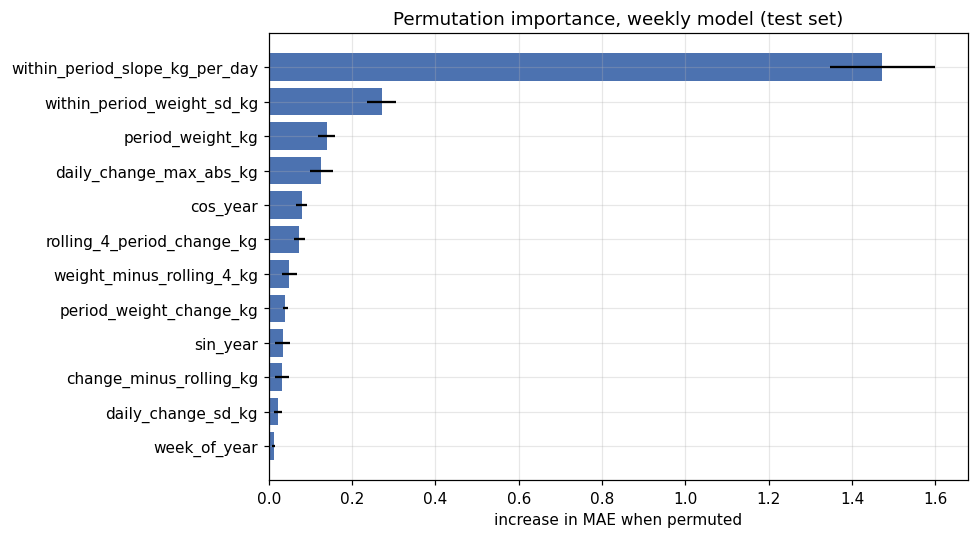

,feature,importance_mean,importance_sd
0,within_period_slope_kg_per_day,1.47258,0.12582
1,within_period_weight_sd_kg,0.27071,0.03460
2,period_weight_kg,0.13886,0.01979
3,daily_change_max_abs_kg,0.12562,0.02744
4,cos_year,0.07861,0.01284
5,rolling_4_period_change_kg,0.07352,0.01347
6,weight_minus_rolling_4_kg,0.04938,0.01821
7,period_weight_change_kg,0.03985,0.00658
8,sin_year,0.03361,0.01827
9,change_minus_rolling_kg,0.03191,0.01638


In [16]:
last_fold = folds[-1]
winner = models.make_regressor("rf", seed=SEED).fit(
    matrix.X.iloc[last_fold.train_index], matrix.y.iloc[last_fold.train_index]
)
importance = models.permutation_feature_importance(
    winner, matrix.X.iloc[last_fold.test_index], matrix.y.iloc[last_fold.test_index], n_repeats=10
).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance.feature[::-1], importance.importance_mean[::-1],
        xerr=importance.importance_sd[::-1], color="#4c72b0")
ax.set(xlabel="increase in MAE when permuted",
       title="Permutation importance, weekly model (test set)")
plt.tight_layout(); plt.show()
display(importance.round(5))

**The dominant feature has no daily analogue.** `within_period_slope_kg_per_day` — the OLS
trend of daily weight across the current week — is worth roughly 5× the next feature. The
daily model's dominant feature was `previous_day_weight_change_kg`, yesterday's change.

The distinction matters mechanically. Yesterday's change is one noisy difference. The
within-week slope is a least-squares trend through 5–7 readings, so it estimates the same
quantity — the colony's current rate of mass change — with far less variance. Next in the
table are `within_period_weight_sd_kg` and `daily_change_max_abs_kg`, which are both
measures of *how erratic* the week was, not how much it gained.

The reading: at this grain the model is using the shape of the week, and the shape is only
visible because the daily rows were kept and summarised rather than averaged away. An
aggregation that had produced only period means would have discarded the best predictor in
the table.

The collinearity caveat from the daily milestone applies unchanged. Permutation importance
under correlated features understates every member of a correlated group, and the weight
chain here is correlated by construction.

## 6. Results and Interpretation

### 6.1 Where the weekly model works and where it fails

Metrics pooled across all four folds' out-of-sample predictions, so every season is
represented — the last fold alone covers January to July and contains 22 summer weeks.

,segment,value,mae,rmse,r2,bias,n,skill_vs_naive
0,season,Autumn,1.2131,2.4436,-0.1578,-0.0635,643,0.3811
1,season,Spring,2.2659,3.9472,0.3099,-0.5129,557,-0.1560
2,season,Summer,2.4209,4.4203,0.3421,0.1262,413,-0.2351
3,season,Winter,0.7454,1.9405,-0.3728,-0.0589,484,0.6197


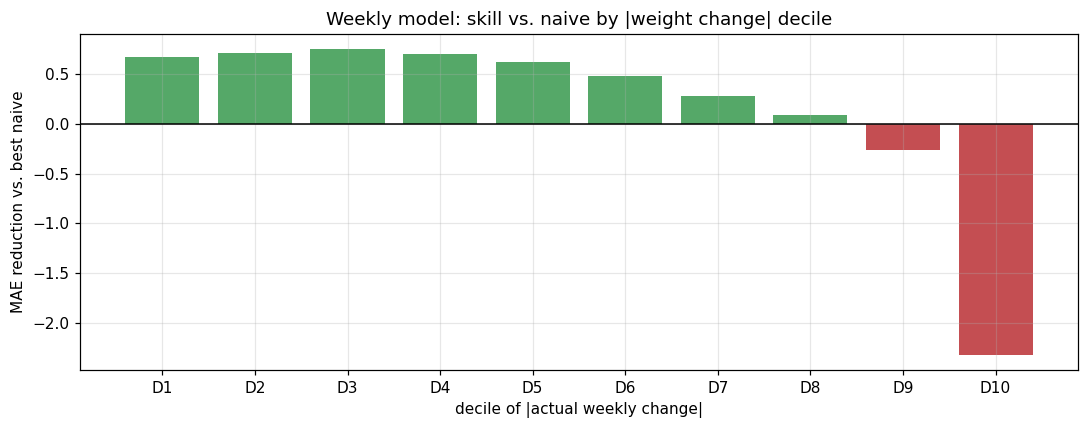

,value,mae,n,skill_vs_naive
4,D1,0.6410,210,0.6730
6,D2,0.5554,210,0.7167
7,D3,0.4915,209,0.7493
8,D4,0.5829,210,0.7026
9,D5,0.7472,210,0.6188
10,D6,1.0209,209,0.4792
11,D7,1.4107,210,0.2803
12,D8,1.7866,209,0.0885
13,D9,2.4673,210,-0.2588
5,D10,6.5156,210,-2.3240


In [17]:
out_of_fold = []
for fold in folds:
    model = models.make_regressor("rf", seed=SEED).fit(
        matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
    )
    block = matrix.meta.iloc[fold.test_index].copy()
    block["y_true"] = matrix.y.iloc[fold.test_index].to_numpy()
    block["y_pred"] = model.predict(matrix.X.iloc[fold.test_index])
    block["fold"] = fold.name
    out_of_fold.append(block)
out_of_fold = pd.concat(out_of_fold, ignore_index=True)

pooled_bar = baselines.groupby("fold").mae.min().mean()
segmented = ev.segmented_report(
    out_of_fold.y_true, out_of_fold.y_pred,
    out_of_fold.rename(columns={pr.PERIOD_END: "measurement_date"}),
    by=("season", "weight_change_decile"), baseline_mae=pooled_bar,
)
display(segmented[segmented.segment == "season"].round(4))

decile = segmented[segmented.segment == "weight_change_decile"].copy()
decile["order"] = decile.value.str.lstrip("D").astype(int)
decile = decile.sort_values("order")
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(decile.value, decile.skill_vs_naive,
       color=["#55a868" if s > 0 else "#c44e52" for s in decile.skill_vs_naive])
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Weekly model: skill vs. naive by |weight change| decile",
       xlabel="decile of |actual weekly change|", ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()
display(decile[["value", "mae", "n", "skill_vs_naive"]].round(4))

| Season | MAE | Skill vs. naive | Daily equivalent |
|---|---|---|---|
| Winter | 0.745 | **+62%** | +34% |
| Autumn | 1.213 | **+38%** | +51% |
| Spring | 2.266 | **−16%** | — |
| Summer | 2.421 | **−24%** | **−95%** |

**The seasonal failure mode survives the grain change, but it is four times less severe.**
The daily model was 95% worse than predicting zero in summer — actively harmful in exactly
the season a beekeeper needs a forecast. The weekly model is 24% worse. Still negative,
still the wrong sign, but the difference between "unusable" and "not yet good enough".

The decile view tells the same story with the same shape as the daily model: skill is
positive on deciles 1 through 8 and negative on the top two, worst on the largest
(−2.32 against the daily model's −5.5). It remains a good model of quiet weeks, and the
gains a beekeeper cares about are in D9 and D10.

Nothing in the re-grain fixes the underlying problem, and it should be named plainly: this
model beats its baseline by being right about weeks where very little happens. The
aggregation halves the damage in the high-variance regime without changing which regime is
which.

### 6.2 Head-to-head with the daily pipeline

,grain,framing,mae,r2,skill_vs_naive,n_rows,source
0,day,best single-stage (HistGB),0.5420,0.0360,-0.0600,26215,Milestone_4.ipynb 5.1
1,day,"two-stage, hard gate",0.4790,0.0440,0.0590,26215,Milestone_4.ipynb 5.3
2,week,best single-stage (history / RF),1.7020,0.1445,0.0866,3012,this notebook 5.1
3,week,"two-stage, hard gate",1.6296,0.2208,0.1516,3012,this notebook 5.3
4,month,best single-stage (history+sensors+events+hive...,4.3130,0.2812,0.1229,622,this notebook 5.2


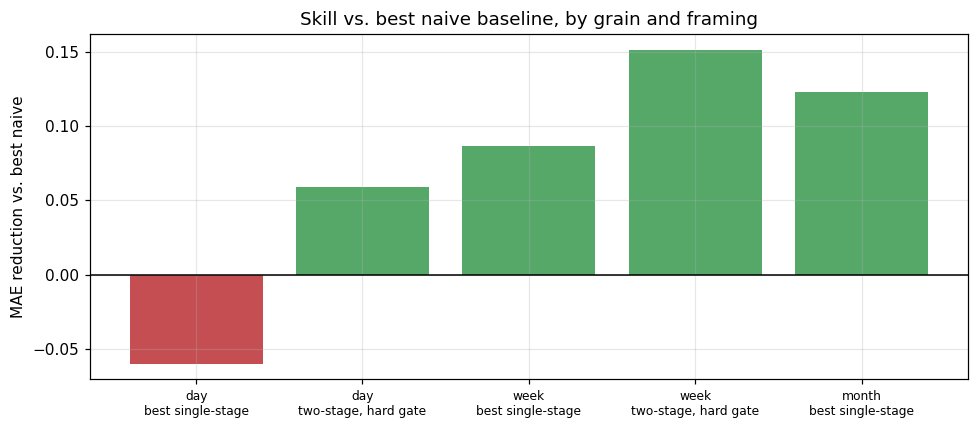

In [18]:
best_week = ev.fold_summary(week_board).iloc[0]
best_month = ev.fold_summary(month_board).iloc[0]
two_stage_week = framings[framings.framing == "two-stage, hard gate"]

comparison = pd.DataFrame([
    {"grain": "day",   "framing": "best single-stage (HistGB)", "mae": 0.542, "r2": 0.036,
     "skill_vs_naive": -0.060, "n_rows": 26215, "source": "Milestone_4.ipynb 5.1"},
    {"grain": "day",   "framing": "two-stage, hard gate",       "mae": 0.479, "r2": 0.044,
     "skill_vs_naive": 0.059,  "n_rows": 26215, "source": "Milestone_4.ipynb 5.3"},
    {"grain": "week",  "framing": f"best single-stage ({best_week.model})",
     "mae": best_week.mae_mean, "r2": best_week.r2_mean, "skill_vs_naive": best_week.skill_mean,
     "n_rows": len(week_df), "source": "this notebook 5.1"},
    {"grain": "week",  "framing": "two-stage, hard gate",       "mae": two_stage_week.mae.mean(),
     "r2": two_stage_week.r2.mean(), "skill_vs_naive": two_stage_week.skill_vs_naive.mean(),
     "n_rows": len(week_df), "source": "this notebook 5.3"},
    {"grain": "month", "framing": f"best single-stage ({best_month.model})",
     "mae": best_month.mae_mean, "r2": best_month.r2_mean, "skill_vs_naive": best_month.skill_mean,
     "n_rows": len(month_df), "source": "this notebook 5.2"},
])
display(comparison.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(comparison)), comparison.skill_vs_naive,
       color=["#55a868" if s > 0 else "#c44e52" for s in comparison.skill_vs_naive])
ax.set_xticks(range(len(comparison)))
ax.set_xticklabels([f"{row.grain}\n{row.framing.split('(')[0].strip()}"
                    for row in comparison.itertuples()], fontsize=8)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Skill vs. best naive baseline, by grain and framing",
       ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()

**Raw MAE is not comparable across grains** — a weekly error of 1.7 kg and a daily error of
0.48 kg measure different quantities, and the weekly target is four times more variable to
begin with. The skill score is the comparable column, because each grain is scored against
its own re-derived naive bar.

On that column the ordering is clear: **week (+15.2% two-stage, +8.7% single-stage) beats
day (+5.9% two-stage, −6.0% single-stage)**, and month is nominally best on single-stage
skill but rests on 622 rows.

## 7. Conclusions and Recommendations

### 7.1 What we can claim

- **Re-graining to a week is the single largest improvement in this project so far.** A
  two-stage pipeline at weekly grain reaches +15.2% skill against the best naive baseline,
  against +5.9% for the same architecture at daily grain.
- **Weekly is the first grain at which a single-stage model beats predicting zero**
  (+8.7%, RF on history features). The daily milestone's negative result was a property of
  the horizon, not of the models.
- **The target's anchor decides the outcome.** Anchoring on period mean weight rather than
  the last observed day flips the result from losing to the baseline to beating it, at both
  grains, with everything else held constant.
- **The dominant predictor changes.** At daily grain it is yesterday's change; at weekly
  grain it is the within-week OLS slope of daily weight, at roughly 5× the next feature.
- **Random Forest beats boosting at this grain**, reversing the daily finding, across five
  seeds with non-overlapping ranges.
- **The model still generalises to unseen hives** — leave-hives-out MAE 1.608 ± 0.125
  against a temporal 1.702.

### 7.2 What we cannot claim

- **Monthly is underpowered.** +12.3% skill on 433 scored rows across four folds from 3.5
  years of one country's weather, with 6-11 observations per feature. Promising; not yet
  evidence.
- **Summer is still negative** (−24% skill). Better than the daily model's −95%, but the
  model is still worse than predicting no change during the nectar flow — the only period
  a beekeeper would consult it.
- **The embargo's value is unmeasured here.** It is required for correctness, and on this
  dataset removing it does not inflate the score. That is a fact about these 100 boundary
  rows, not a general finding.
- **Weight change is still not honey yield.** At weekly and monthly grain a harvest lands
  *inside* the forecast window and subtracts 10–20 kg of exactly the quantity being
  predicted. Section 7.3 treats this as the main open problem.

### 7.3 Recommended next steps

1. **Model gross gain, not net weight change.** The `honey` event log records when a
   harvest happened but not how much was removed. Reconstructing removed mass from the
   weight series — a step change coincident with a logged harvest — would turn the target
   into something closer to honey production. This is the change with the largest expected
   payoff and it is not a modelling change, it is a target change.
2. **Give the summer regime its own model.** Skill is +62% in winter and −24% in summer
   with one pooled model. A season-conditional model, or a mixture with a seasonal gate,
   directly attacks the failure mode instead of averaging over it.
3. **Add weather.** `honey_weather.parquet` is referenced by the daily feature set but is
   not in the repository. Weekly rainfall and degree-day totals are far more plausibly
   predictive of a week's nectar flow than a single day's reading is of tomorrow's, and
   `foraging_days` — the crudest possible proxy — already carries measurable weight.
4. **Make the extreme threshold per-hive relative.** 11.1 kg on a 10 kg nucleus and on a
   100 kg production hive are not the same event. `hive_target_mad_kg` already exists in
   the daily table for exactly this.
5. **More years before trusting the monthly result.** The monthly board's +12.3% is the
   best skill score in the notebook and the one least supported by its sample. Two more
   seasons would roughly double the monthly row count and make the fold-to-fold spread
   interpretable rather than merely small.

## Appendix A — Anatomy of one weekly row

In [19]:
full_weeks = week_df[week_df.days_observed == 7].reset_index(drop=True)
example = full_weeks.iloc[[len(full_weeks) // 2]].T
example.columns = ["value"]
display(example.head(45))

schema = pd.DataFrame({"column": week_df.columns, "dtype": [str(t) for t in week_df.dtypes]})
schema["forbidden_as_feature"] = schema.column.isin(pr.PERIOD_FORBIDDEN)
schema["in_history_rung"] = schema.column.isin(pr.PERIOD_FEATURE_SETS["history"])
display(schema)

,value
hive_id,90
period_index,2641
days_observed,7
period_start_date,2020-08-03 00:00:00
period_end_date,2020-08-09 00:00:00
period_last_weight_kg,33.925979
period_first_weight_kg,34.768276
period_mean_weight_kg,35.049131
period_max_weight_kg,36.629583
period_min_weight_kg,33.925979


,column,dtype,forbidden_as_feature,in_history_rung
0,hive_id,int32,False,False
1,period_index,int64,False,False
2,days_observed,int64,False,True
3,period_start_date,datetime64[ns],False,False
4,period_end_date,datetime64[ns],False,False
...,...,...,...,...
65,week_of_year,int64,False,True
66,sin_year,float64,False,True
67,cos_year,float64,False,True
68,season,object,False,False


## Appendix B — Designs considered and not taken

**Iterated multi-step forecasting.** Rather than re-graining the data, keep the daily model
and roll it forward seven times, feeding each prediction back as the next day's input. This
is a legitimate alternative and would preserve the full 26,215-row training set. It was not
pursued because the daily model does not beat predicting zero at step 1, so its errors
compound from a base that is already worse than a constant; and because the recursion
requires predicting the whole feature vector forward, not just the target, which turns one
modelling problem into eight.

**Fixed-endpoint cumulative forecasting.** The question a beekeeper actually asks is not
"how much next week" but "how much by the August harvest" — a shrinking-horizon,
fixed-endpoint problem. It needs its own target, its own baselines (climatology-to-date is
strong), and a horizon feature, and the metric has to be reported per weeks-remaining
because a 12-week-out forecast and a 1-week-out forecast are not the same task. This is the
framing with the most direct beekeeper value and is the natural sequel to this notebook.

**Per-hive relative targets.** Dividing the change by the hive's own scale would make a
nucleus colony and a production hive comparable and would fix the absolute-threshold
problem in one move. It also changes what MAE means and breaks comparability with every
number in `Milestone_4.ipynb`, so it belongs in a milestone that can re-baseline
everything.

## Appendix C — Reproduction checklist

| Check | Where |
|---|---|
| Clean-checkout run, no network, no credentials | this notebook |
| Row-count waterfall for the re-grain | Section 2.2 |
| The anchor choice measured, not assumed | Section 2.3 |
| No leakage — forbidden period columns rejected, with a negative test | Section 2.4 |
| Extreme threshold re-derived in sd units, not carried over | Section 3.2 |
| Embargo at every split boundary, with its cost measured | Section 4.1 |
| Split integrity asserted on label dates, every fold | Section 4.2 |
| Baselines re-set for the new grain, including climatology | Section 4.3 |
| Skill score against the best naive, every model, every fold | Sections 5.1, 5.2 |
| Two-stage honesty — oracle numbers labelled UPPER BOUND | Section 5.3 |
| Cross-validation — rolling-origin and leave-hives-out, mean ± sd | Sections 4.2, 5.4 |
| Seed stability before any ranking claim | Section 5.4 |
| Segmented tables — season and \|change\| decile, pooled out-of-fold | Section 6.1 |
| Comparison to the daily pipeline on the one comparable metric | Section 6.2 |